# Clase 06 — Evaluación de modelos: métricas técnicas y económicas
## People Analytics — ¿qué tan bueno es nuestro modelo?

**Analítica de Datos · Negocios Digitales · UdeSA · Otoño 2026**

---

### Contexto

Seguimos siendo el equipo de **People Analytics** de una consultora de tecnología. En Clase 05 ya entrenamos modelos de aceptación de oferta. Lo que faltaba era responder la pregunta más importante para el negocio:

> **¿Cómo sabemos si nuestro modelo es bueno? ¿Qué número le llevamos al CFO para que firme el rollout?**

El problema es que *"bueno"* depende del costo de cada tipo de error:

- **Falso Positivo** — el modelo predice que el candidato **acepta** la oferta estándar, pero en realidad **rechaza**. La posición queda abierta, hay que re-buscar. Esto le sale caro al negocio (~$500.000 ARS por proceso).
- **Falso Negativo** — el modelo predice que el candidato **no acepta**, así que el área de Comp arma un paquete reforzado de antemano. Pero el candidato hubiera aceptado el paquete estándar. Pagamos sueldo de más sin necesidad (~$200.000 ARS al año por candidato).

Los dos errores cuestan distinto. Por eso accuracy sola no alcanza.

### Lo que hacemos hoy

1. Repasamos el dataset y entrenamos tres modelos baseline (Regresión Logística, KNN, Árbol).
2. Recorremos las métricas técnicas: matriz de confusión, accuracy, precision, recall, F1, ROC/AUC, curva precision-recall.
3. Llevamos las métricas a plata: matriz de costos + elección del umbral óptimo.
4. Decidimos qué modelo va a producción y por qué.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report,
)

sns.set_style("whitegrid")

# Colores consistentes: verde = aceptó / rojo = rechazó
VERDE, ROJO = "#2E7D32", "#C62828"
PALETA = {"Logística": "#1565C0", "KNN": "#F57C00", "Árbol": "#6A1B9A"}

---
## 2. Repaso del caso y de los datos

Cada fila es un candidato a quien la consultora le hizo una oferta formal. El target `acepta_oferta` indica si terminó aceptando (1) o no (0).

In [2]:
df = pd.read_csv("candidatos_ofertas.csv")
print(f"Dimensiones: {df.shape[0]} candidatos x {df.shape[1]} columnas")
df.head()

Dimensiones: 1510 candidatos x 7 columnas


,antiguedad_empleo_actual_meses,diferencial_salarial_ofrecido_pct,cantidad_entrevistas_realizadas,dias_desde_primer_contacto,seniority,modalidad_trabajo,acepta_oferta
0,58,22.4,3.0,30,ssr,hibrido,0
1,41,35.6,4.0,73,ssr,hibrido,1
2,21,15.9,4.0,24,ssr,remoto,1
3,27,35.7,4.0,14,sr,presencial,1
4,46,24.4,5.0,21,ssr,remoto,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   antiguedad_empleo_actual_meses     1510 non-null   int64  
 1   diferencial_salarial_ofrecido_pct  1510 non-null   float64
 2   cantidad_entrevistas_realizadas    1502 non-null   float64
 3   dias_desde_primer_contacto         1510 non-null   int64  
 4   seniority                          1510 non-null   object 
 5   modalidad_trabajo                  1510 non-null   object 
 6   acepta_oferta                      1510 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 82.7+ KB


In [4]:
# Balance del target — primera mirada para decidir si conviene usar accuracy como métrica principal
conteo = df["acepta_oferta"].value_counts()
proporcion = df["acepta_oferta"].value_counts(normalize=True).round(3)

print("Cantidad de candidatos por clase:")
print(conteo)
print("\nProporción:")
print(proporcion)

Cantidad de candidatos por clase:
acepta_oferta
1    906
0    604
Name: count, dtype: int64

Proporción:
acepta_oferta
1    0.6
0    0.4
Name: proportion, dtype: float64


El dataset está **bastante balanceado** (60% acepta, 40% rechaza). Accuracy no va a ser totalmente engañoso, pero igual vamos a ver por qué conviene mirar precision y recall por separado.

---
## 3. Preparación y entrenamiento de modelos baseline

Hacemos lo mínimo para tener los modelos andando — la calidad de la preparación no es el foco de hoy. Entrenamos **tres modelos** para tener algo que comparar:

- **Regresión Logística** — la baseline interpretable.
- **KNN** — la baseline geométrica.
- **Árbol de decisión** — un modelo no lineal que captura interacciones.

Si el modelo más complejo no le gana a la logística, probablemente la logística es la elección correcta.

In [5]:
# Imputamos los 8 nulos de cantidad_entrevistas con la mediana — son pocos, no vale la pena descartar filas
df["cantidad_entrevistas_realizadas"] = df["cantidad_entrevistas_realizadas"].fillna(
    df["cantidad_entrevistas_realizadas"].median()
)

# Dummies para las dos categóricas
df_modelo = pd.get_dummies(df, columns=["seniority", "modalidad_trabajo"], drop_first=True)

# Features y target
features = [c for c in df_modelo.columns if c != "acepta_oferta"]
X = df_modelo[features]
y = df_modelo["acepta_oferta"]

# Split estratificado (mantiene la proporción del target en train y test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Escalado solo para KNN — Logística y Árbol no lo necesitan, pero no hace daño
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 1057  |  Test: 453


In [6]:
# Entrenamos los tres modelos
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_sc, y_train)

arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
arbol.fit(X_train, y_train)

# Guardamos predicciones y probabilidades para usarlas más adelante
pred = {
    "Logística": log.predict(X_test),
    "KNN":       knn.predict(X_test_sc),
    "Árbol":     arbol.predict(X_test),
}
proba = {
    "Logística": log.predict_proba(X_test)[:, 1],
    "KNN":       knn.predict_proba(X_test_sc)[:, 1],
    "Árbol":     arbol.predict_proba(X_test)[:, 1],
}

print("Modelos entrenados.")

Modelos entrenados.


---
## 4. Matriz de confusión

La **matriz de confusión** es la base de todas las métricas. Tiene cuatro cuadrantes:

|  | Predijo: Rechaza (0) | Predijo: Acepta (1) |
|---|---|---|
| **Real: Rechaza (0)** | Verdadero Negativo (TN) | **Falso Positivo (FP)** |
| **Real: Acepta (1)** | **Falso Negativo (FN)** | Verdadero Positivo (TP) |

**Lectura en este caso:**

- **FP** — el modelo dijo que acepta y no aceptó. Comp armó paquete estándar, candidato rechaza, **posición queda abierta** y hay que re-buscar.
- **FN** — el modelo dijo que no acepta y aceptaba igual. Comp armó paquete reforzado innecesariamente → **pagamos de más** todo el año.

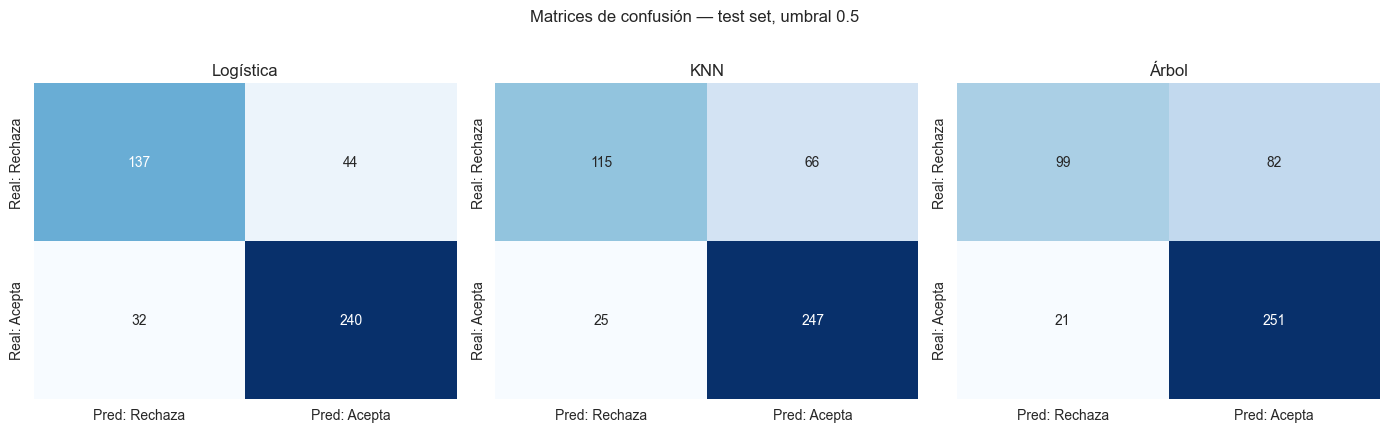

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (nombre, y_pred) in zip(axes, pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred: Rechaza", "Pred: Acepta"],
        yticklabels=["Real: Rechaza", "Real: Acepta"],
    )
    ax.set_title(nombre)
plt.suptitle("Matrices de confusión — test set, umbral 0.5", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

**Mirando las matrices:**

- Cada modelo distribuye los errores distinto. Algunos hacen más FP, otros más FN.
- Decidir cuál es mejor depende del **costo de cada tipo de error** — eso lo cuantificamos más adelante.

---
## 5. Métricas básicas: accuracy, precision, recall, F1

Las cuatro métricas más usadas para clasificación. Cada una contesta una pregunta distinta.

| Métrica | Pregunta que contesta | Fórmula |
|---|---|---|
| **Accuracy** | De TODAS las predicciones, ¿qué % acerté? | `(TP + TN) / total` |
| **Precision** | De las que predije "acepta", ¿qué % efectivamente aceptó? | `TP / (TP + FP)` |
| **Recall** | De los que aceptaron, ¿a qué % los detecté? | `TP / (TP + FN)` |
| **F1** | Promedio armónico entre precision y recall | `2 · P · R / (P + R)` |

**¿Cuándo importa cada una?**

- Si el **costo de un FP es alto** → priorizo **precision** (no quiero predecir acepta a alguien que no acepta).
- Si el **costo de un FN es alto** → priorizo **recall** (no quiero perderme a alguien que sí aceptaba).
- Si quiero balance, miro **F1**.
- **Accuracy engaña** cuando las clases están muy desbalanceadas. Acá no es el caso (60/40) pero conviene saberlo.

In [8]:
filas = []
for nombre, y_pred in pred.items():
    filas.append({
        "Modelo":    nombre,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
    })
metricas = pd.DataFrame(filas).round(3)
metricas

,Modelo,Accuracy,Precision,Recall,F1
0,Logística,0.832,0.845,0.882,0.863
1,KNN,0.799,0.789,0.908,0.844
2,Árbol,0.773,0.754,0.923,0.830


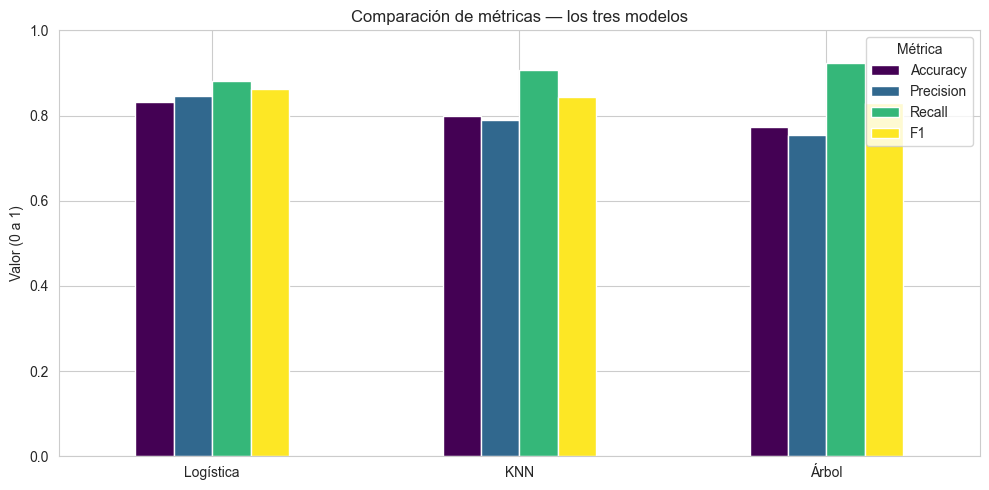

In [9]:
# Mismo cuadro pero como gráfico de barras agrupadas — más fácil de leer en clase
fig, ax = plt.subplots(figsize=(10, 5))
metricas_g = metricas.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]]
metricas_g.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="white")
ax.set_title("Comparación de métricas — los tres modelos")
ax.set_ylabel("Valor (0 a 1)")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Métrica")
plt.tight_layout()
plt.show()

**Observaciones:**

- Si dos modelos tienen accuracy parecida pero distinta precision/recall, **están eligiendo errores diferentes**. Ninguno es "mejor" en abstracto — depende del contexto de negocio.
- Para tomar la decisión final necesitamos cuantificar el costo de cada error. Eso llega en la sección 8.

---
## 6. Curva ROC y AUC

Las métricas de la sección 5 se calculan **fijando un umbral** (0.5 por defecto). Pero el umbral lo elige el negocio. Si queremos comparar modelos **independientemente del umbral**, miramos la **curva ROC**.

- **TPR** (True Positive Rate = Recall) = `TP / (TP + FN)` — de los que aceptan, qué % detecto.
- **FPR** (False Positive Rate) = `FP / (FP + TN)` — de los que no aceptan, a qué % le digo erróneamente que aceptan.

La curva ROC dibuja TPR vs FPR a medida que muevo el umbral de 1 a 0.

- Una curva pegada a la esquina superior izquierda = modelo casi perfecto.
- Una curva sobre la diagonal = modelo no mejor que tirar una moneda.

**AUC** (Area Under the Curve) condensa todo en un solo número: probabilidad de que el modelo le asigne mayor probabilidad a un "acepta" que a un "no acepta" tomados al azar. Bueno para comparar modelos rápido.

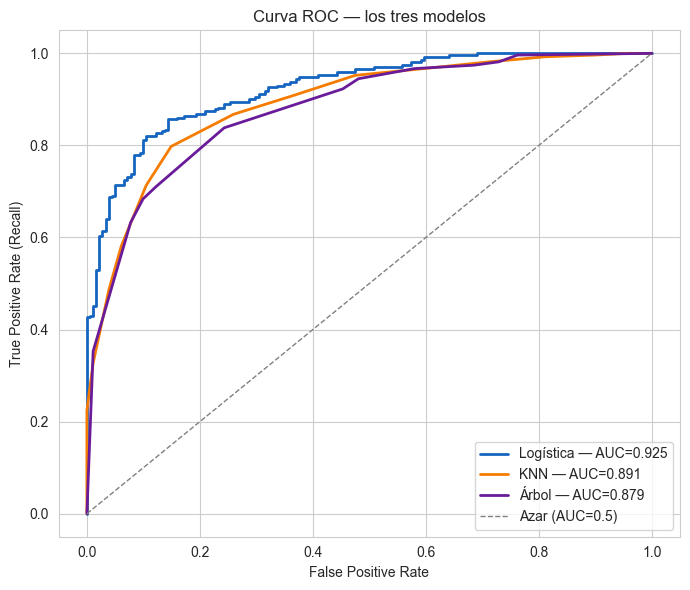

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, scores in proba.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=PALETA[nombre], lw=2, label=f"{nombre} — AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Azar (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Curva ROC — los tres modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura rápida:**

- El modelo con AUC más alto es el que mejor separa las dos clases en todo el rango de umbrales.
- ROC es útil cuando las clases están **razonablemente balanceadas**. Con mucho desbalance hay que mirar la curva precision-recall (siguiente sección).

---
## 7. Curva Precision-Recall

Cuando la clase positiva es **rara** (por ejemplo, fraude bancario: 1 en 1000 transacciones), la ROC puede mostrar una curva engañosamente buena porque el FPR queda chico aunque haya muchos falsos positivos en términos absolutos.

La curva **Precision-Recall** muestra precision vs recall a medida que movés el umbral. Es más honesta cuando hay desbalance.

Acá las clases están relativamente balanceadas (60/40), así que ROC y PR van a contar historias parecidas. Pero conviene tener la herramienta en el toolkit.

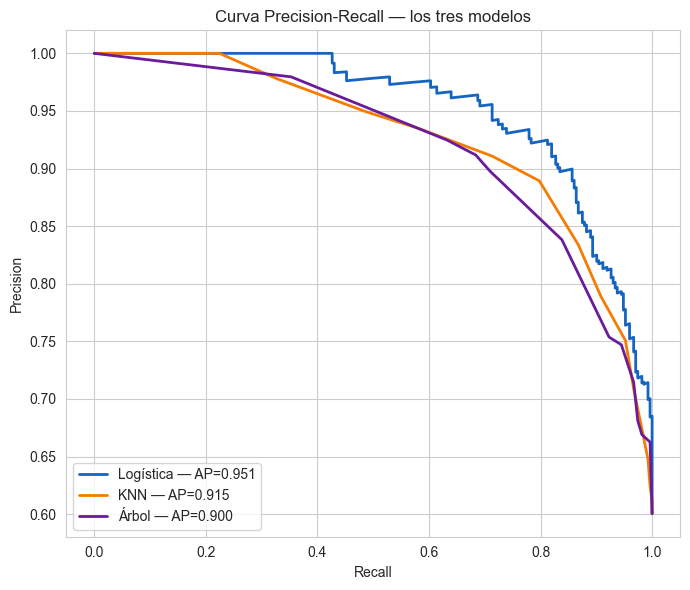

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, scores in proba.items():
    precision_arr, recall_arr, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(recall_arr, precision_arr, color=PALETA[nombre], lw=2,
            label=f"{nombre} — AP={ap:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — los tres modelos")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**AP** (Average Precision) es el área bajo la curva precision-recall — análogo a AUC pero para PR. Mientras más alto, mejor el modelo en este contexto.

---
## 8. Análisis económico — llevamos las métricas a plata

Las métricas técnicas no responden "qué modelo va a producción". Eso lo decide el **costo en pesos** de cada error.

| Tipo de error | Qué pasa en el caso | Costo estimado |
|---|---|---|
| **FP** | Predijo acepta, no aceptó. Posición queda abierta → re-buscar | **$500.000** por proceso |
| **FN** | Predijo rechaza, hubiera aceptado. Paquete reforzado innecesario | **$200.000** al año por candidato |

Para cada modelo calculamos el **costo total** en el test set y vemos cuál sale más barato.

In [12]:
COSTO_FP = 500_000
COSTO_FN = 200_000

filas = []
for nombre, y_pred in pred.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    costo_total = fp * COSTO_FP + fn * COSTO_FN
    filas.append({
        "Modelo":    nombre,
        "FP":        fp,
        "FN":        fn,
        "Costo FP ($)": fp * COSTO_FP,
        "Costo FN ($)": fn * COSTO_FN,
        "Costo total ($)": costo_total,
    })
costos = pd.DataFrame(filas)

def formato_pesos(x):
    return f"${x:,.0f}"

for col in ["Costo FP ($)", "Costo FN ($)", "Costo total ($)"]:
    costos[col] = costos[col].apply(formato_pesos)

costos

,Modelo,FP,FN,Costo FP ($),Costo FN ($),Costo total ($)
0,Logística,44,32,"$22,000,000","$6,400,000","$28,400,000"
1,KNN,66,25,"$33,000,000","$5,000,000","$38,000,000"
2,Árbol,82,21,"$41,000,000","$4,200,000","$45,200,000"


### Movemos el umbral del mejor modelo

Ahora viene la pregunta clave: **¿qué umbral minimiza el costo total?** El umbral 0.5 es solo el default — el negocio puede elegir otro.

Mejor modelo por AUC: Logística  (AUC=0.925)


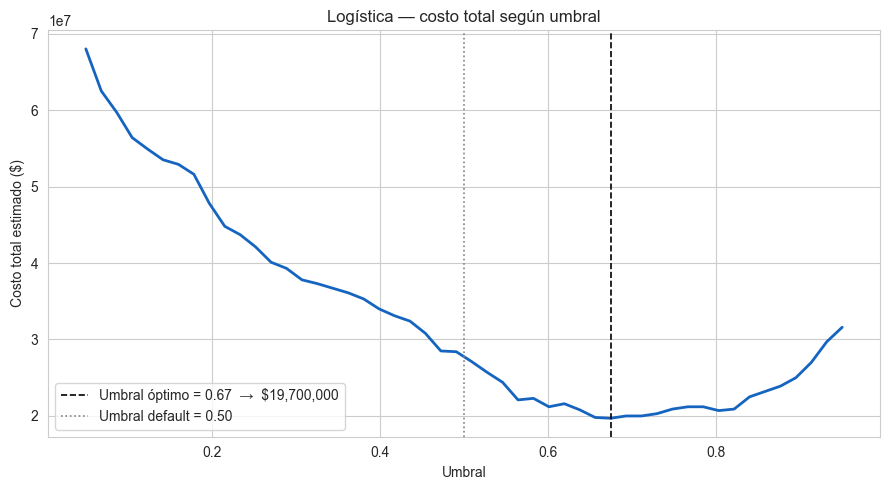


Umbral óptimo: 0.67
Costo mínimo:  $19,700,000
Costo con umbral 0.50: $31,600,000


In [13]:
# Elegimos el modelo con mejor AUC para optimizar umbral
aucs = {n: roc_auc_score(y_test, s) for n, s in proba.items()}
mejor_modelo = max(aucs, key=aucs.get)
print(f"Mejor modelo por AUC: {mejor_modelo}  (AUC={aucs[mejor_modelo]:.3f})")

scores = proba[mejor_modelo]
umbrales = np.linspace(0.05, 0.95, 50)
costos_por_umbral = []
for u in umbrales:
    y_hat = (scores >= u).astype(int)
    cm = confusion_matrix(y_test, y_hat)
    tn, fp, fn, tp = cm.ravel()
    costos_por_umbral.append(fp * COSTO_FP + fn * COSTO_FN)

u_optimo = umbrales[int(np.argmin(costos_por_umbral))]
costo_optimo = min(costos_por_umbral)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(umbrales, costos_por_umbral, color=PALETA[mejor_modelo], lw=2)
ax.axvline(u_optimo, color="black", ls="--", lw=1.2,
           label=f"Umbral óptimo = {u_optimo:.2f}  →  ${costo_optimo:,.0f}")
ax.axvline(0.5, color="grey", ls=":", lw=1.2, label="Umbral default = 0.50")
ax.set_xlabel("Umbral")
ax.set_ylabel("Costo total estimado ($)")
ax.set_title(f"{mejor_modelo} — costo total según umbral")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nUmbral óptimo: {u_optimo:.2f}")
print(f"Costo mínimo:  ${costo_optimo:,.0f}")
print(f"Costo con umbral 0.50: ${fp * COSTO_FP + fn * COSTO_FN:,.0f}")

**Lectura de negocio:**

- Cambiar el umbral del default 0.5 al óptimo le ahorra plata al negocio sin cambiar el modelo.
- El umbral óptimo depende **siempre** del costo relativo entre FP y FN. Si mañana el costo de re-buscar baja a la mitad, el umbral óptimo también cambia.
- Este análisis es lo que finalmente se le presenta al CFO: no "el accuracy es 0.78", sino "con este modelo y este umbral ahorramos $X al año".

---
## 9. Decisión final

Recapitulamos lo que aprendimos:

1. **Cuál modelo va a producción** — el que minimiza el costo en pesos, no necesariamente el de mayor accuracy.
2. **Qué umbral usa** — el óptimo según la matriz de costos del negocio, no el 0.5 por default.
3. **Cómo lo justificamos** — con el ahorro esperado en pesos, no con el F1 score.

El reporte final al CFO tiene que decir tres cosas:

> *"Recomendamos el modelo X con umbral Y. Sobre el último año habría ahorrado $Z respecto al proceso manual actual. El modelo se equivoca en N1 candidatos por mes (FP) y N2 candidatos por mes (FN), y eso es lo que cuesta operarlo."*

---
## Para ver en casa

Tres ejercicios para practicar antes del parcial:

1. **Inversión de costos** — si el costo de un FN sube a $800.000 (porque ahora el sueldo extra se paga 4 años, no 1), ¿cambia el umbral óptimo? ¿Por cuánto?
2. **Otro modelo** — entrená un Random Forest con `RandomForestClassifier(n_estimators=200)`. ¿Le gana al mejor modelo de hoy?
3. **Reporte de clasificación** — ejecutá `classification_report(y_test, pred["Logística"])` y explicale a un compañero qué significa cada columna del output.

In [14]:
# Para arrancar el ejercicio 3 — el reporte ya viene todo formateado
print(classification_report(
    y_test, pred["Logística"],
    target_names=["Rechaza (0)", "Acepta (1)"]
))

              precision    recall  f1-score   support

 Rechaza (0)       0.81      0.76      0.78       181
  Acepta (1)       0.85      0.88      0.86       272

    accuracy                           0.83       453
   macro avg       0.83      0.82      0.82       453
weighted avg       0.83      0.83      0.83       453

